In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("../data/processed/04a_feature_engineering.csv")

kolom = ['harga', 'jarak_kampus_1', 'jarak_kampus_2']
print(df[kolom].describe())
print(df[kolom].skew())

              harga  jarak_kampus_1  jarak_kampus_2
count  3.430000e+02      343.000000      343.000000
mean   2.240639e+06     3553.206997     3126.384840
std    8.281125e+05     1712.912325     1421.929047
min    7.250000e+05      550.000000      900.000000
25%    1.700000e+06     2100.000000     2100.000000
50%    2.140000e+06     3700.000000     2800.000000
75%    2.704750e+06     4800.000000     3900.000000
max    7.000000e+06     7200.000000     8200.000000
harga             1.178157
jarak_kampus_1   -0.099416
jarak_kampus_2    0.750782
dtype: float64


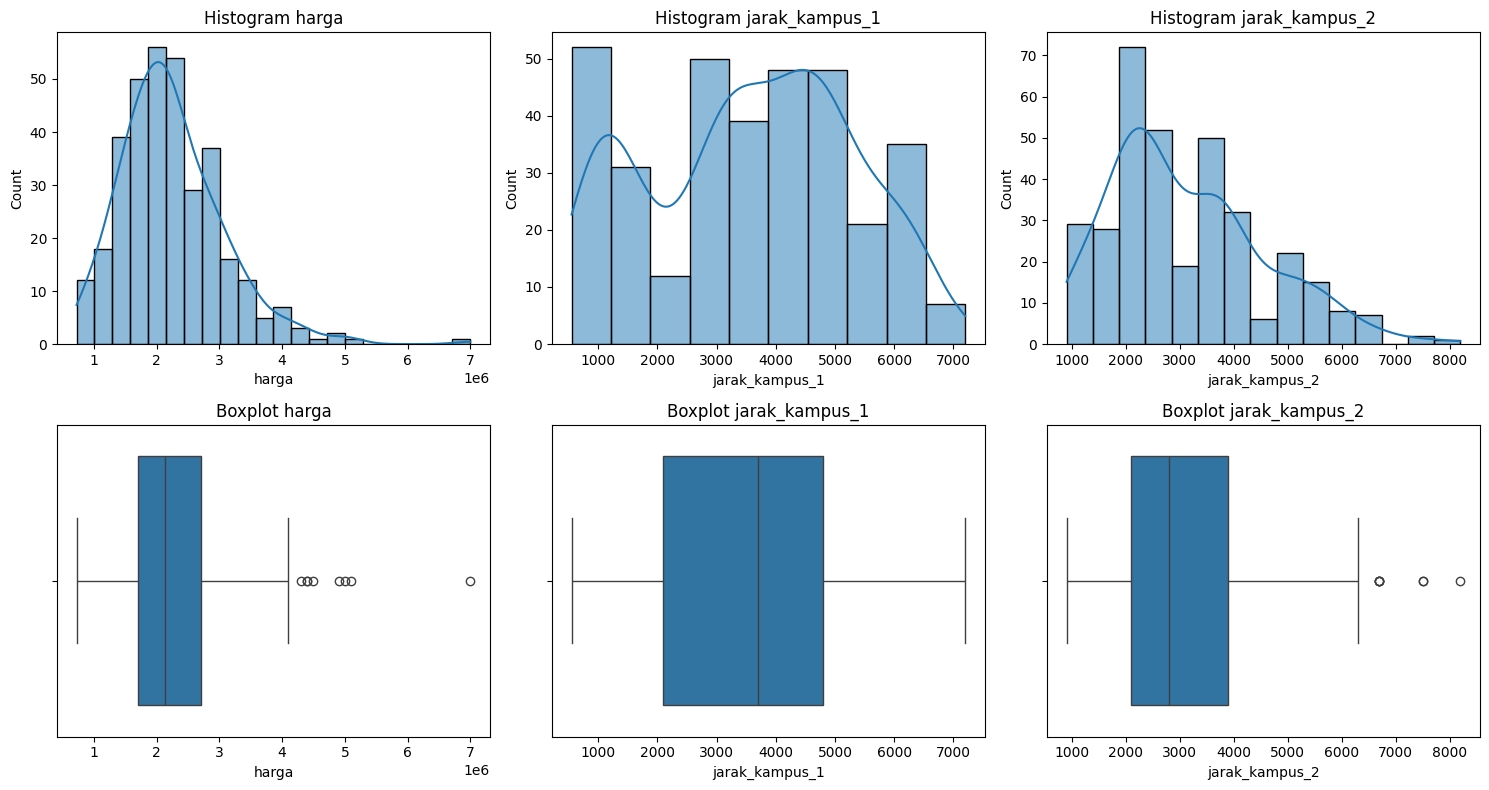

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(kolom):
    sns.histplot(df[col], kde=True, ax=axes[0, i])
    axes[0, i].set_title(f"Histogram {col}")
    sns.boxplot(x=df[col], ax=axes[1, i])
    axes[1, i].set_title(f"Boxplot {col}")
plt.tight_layout()
plt.show()

In [4]:
for col in kolom:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    batas_bawah, batas_atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < batas_bawah) | (df[col] > batas_atas)).sum()
    print(f"{col}: {n_out} outlier ({n_out/len(df):.1%}), batas atas = {batas_atas:,.0f}")

harga: 8 outlier (2.3%), batas atas = 4,211,875
jarak_kampus_1: 0 outlier (0.0%), batas atas = 8,850
jarak_kampus_2: 7 outlier (2.0%), batas atas = 6,600


In [5]:
for col in kolom:
    stat, p = shapiro(df[col].dropna())
    print(col, "normal" if p > 0.05 else "tidak normal", f"(p={p:.4f})")

harga tidak normal (p=0.0000)
jarak_kampus_1 tidak normal (p=0.0000)
jarak_kampus_2 tidak normal (p=0.0000)


In [6]:
print(df[df["harga"] > 4_217_125][["id_kost", "harga", "kamar_mandi_dalam", "ac", "kloset_duduk"]])

        id_kost    harga  kamar_mandi_dalam    ac  kloset_duduk
180  KST-PL0017  4400000               True  True          True
232  KST-PL0028  4500000               True  True         False
256  KST-PL0043  5000000               True  True          True
259  KST-PL0045  4900000               True  True          True
262  KST-PL0047  7000000               True  True          True
268  KST-PL0051  5100000               True  True          True
272  KST-PL0054  4400000               True  True          True
323  KST-PL0078  4300000               True  True          True


In [7]:
print(df[df["jarak_kampus_2"] > 7000][["id_kost", "harga", "jarak_kampus_2"]])

        id_kost    harga  jarak_kampus_2
89   KST-GP0072  1200000            7500
157  KST-GB0011  2000001            8200
190  KST-GP0147  2000000            7500


In [8]:
low, high = df["harga"].quantile([0.01, 0.99])
df["harga_scaled"] = MinMaxScaler().fit_transform(df[["harga"]].clip(low, high))

C:\Users\Dewi Nehe\AppData\Local\Temp\ipykernel_15908\2171791397.py:2: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["harga_scaled"] = MinMaxScaler().fit_transform(df[["harga"]].clip(low, high))


In [9]:
batas_harga = df["harga"].quantile(0.99)
harga_clip = df["harga"].clip(upper=batas_harga)

df["harga_scaled"] = MinMaxScaler().fit_transform(harga_clip.to_frame())

print("Max harga setelah clip:", f"{harga_clip.max():,.0f}")  # harus 4,688,000
print(df["harga_scaled"].describe())
print("Skew sesudah:", df["harga_scaled"].skew().round(2))

Max harga setelah clip: 4,732,000
count    343.000000
mean       0.376013
std        0.197329
min        0.000000
25%        0.243324
50%        0.353132
75%        0.494073
max        1.000000
Name: harga_scaled, dtype: float64
Skew sesudah: 0.74


C:\Users\Dewi Nehe\AppData\Local\Temp\ipykernel_15908\3434363562.py:2: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  harga_clip = df["harga"].clip(upper=batas_harga)
